In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
df = pd.read_excel("/content/gdrive/My Drive/0 - FORECASTING/Monthly POC-01.xlsx")
main_path = '/content/gdrive/My Drive/0 - FORECASTING/'
file_path = os.path.join(main_path, 'Monthly POC-01.xlsx')
main_out = sys.stdout

output_name = 'x-output_file monthly 01 m60.txt'
output_file = os.path.join(main_path, output_name)
sys.stdout = open(output_file, 'w')

print('=========== OUTPUT FILE ===========\n\n')

#string to date format
df['Month'] = pd.to_datetime(df['Month'],infer_datetime_format=True)
df = df.set_index(['Month'])
df.head(5)

,POC
Month,
2002-07-01,141.584996
2002-08-01,154.828717
2002-09-01,138.418435
2002-10-01,142.299674
2002-11-01,118.538709


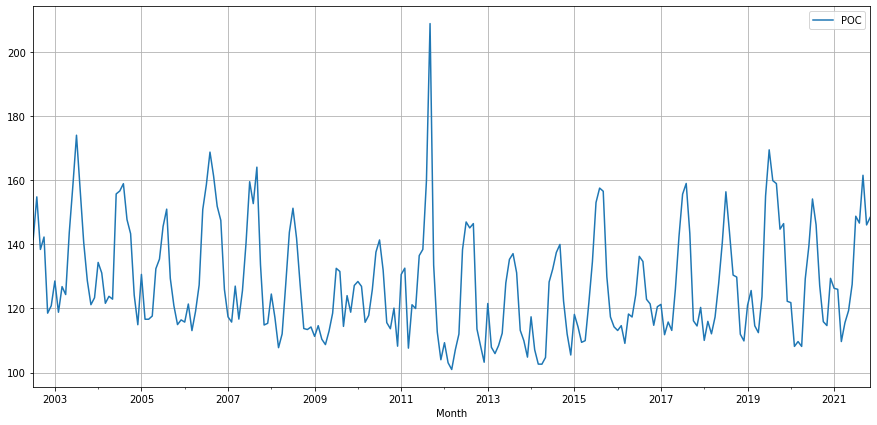

In [4]:
from matplotlib.dates import MonthLocator, DateFormatter, DayLocator
from matplotlib.ticker import NullFormatter

X = df.dropna()

X.plot(figsize=(15, 7))
plt.grid()

#savedir = os.path.join(main_path, 'Figure 01_data_awal-monthly m60.png')
#plt.savefig(savedir)

plt.show()

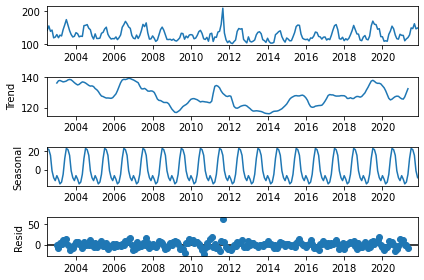

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decompose_data = seasonal_decompose(X, model="additive")
decompose_data.plot()

#savedir = os.path.join(main_path, 'Figure 02_komponen_time_series_monthly m60.png')
#plt.savefig(savedir)

plt.show()

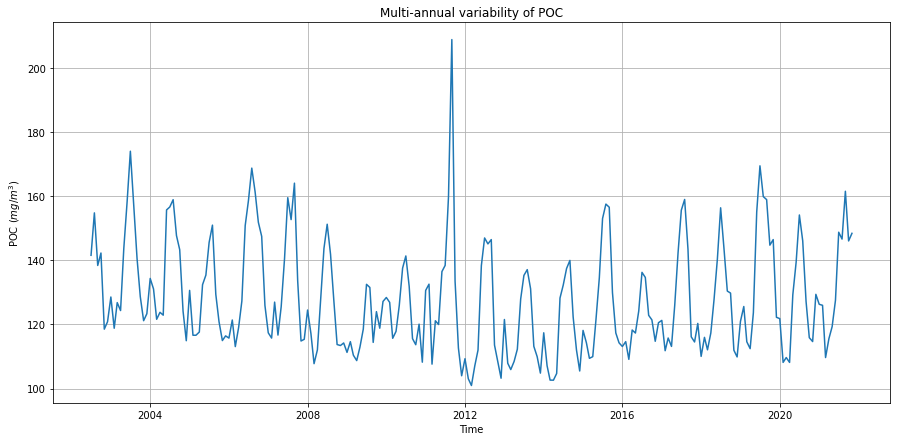

In [6]:
plt.figure(figsize=(15,7))
plt.title("Multi-annual variability of POC")
plt.xlabel('Time')
plt.ylabel('POC ($mg/m^3$)')
plt.plot(df)
plt.grid()
#savedir = os.path.join(main_path, 'xFigure 01_Multi-annual variability of POC-monthly m60.png')
#plt.savefig(savedir)
plt.show()

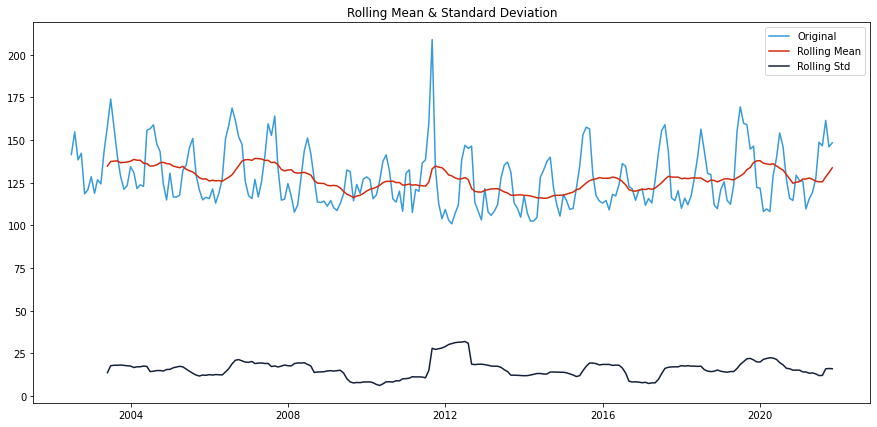

In [7]:
#Determine rolling statistics
df["rolling_avg"] = df["POC"].rolling(window=12).mean() #window size 12 denotes 12 months, giving rolling mean at yearly level
df["rolling_std"] = df["POC"].rolling(window=12).std()

#Plot rolling statistics
plt.figure(figsize=(15,7))
plt.plot(df["POC"], color='#379BDB', label='Original')
plt.plot(df["rolling_avg"], color='#D22A0D', label='Rolling Mean')
plt.plot(df["rolling_std"], color='#142039', label='Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
#savedir = os.path.join(main_path, 'xFigure 02_Rolling Mean & Standard Deviation-monthly m60.png')
#plt.savefig(savedir)
plt.show(block=False)

In [8]:
#Augmented Dickey–Fuller test:
print('Results of Dickey Fuller Test:')
dftest = adfuller(df['POC'], autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
    
print(dfoutput)

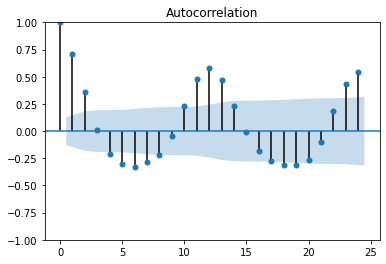

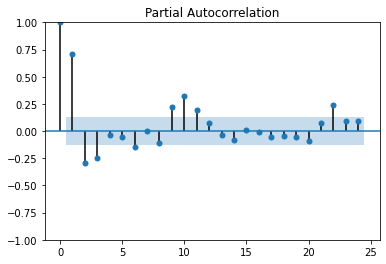

In [9]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
fig = sm.graphics.tsa.plot_acf(X.POC)

#savedir = os.path.join(main_path, 'Figure 06a_ACF-monthly m60.png')
#plt.savefig(savedir)

fig = sm.graphics.tsa.plot_pacf(X.POC)

#savedir = os.path.join(main_path, 'Figure 06b_PACF-monthly m60.png')
#plt.savefig(savedir)

plt.show()

In [10]:
#Standard ARIMA Model
ARIMA_model = pm.auto_arima(df['POC'], 
                      start_p=1, 
                      start_q=1,
                      test='adf', # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                      d=1,# let model determine 'd'
                      seasonal=False, # False for No Seasonality for standard ARIMA; True for adding seasonality
                      trace=False, #logs 
                      error_action='warn', #shows errors ('ignore' silences these)
                      suppress_warnings=True,
                      stepwise=True)
print(ARIMA_model.summary())

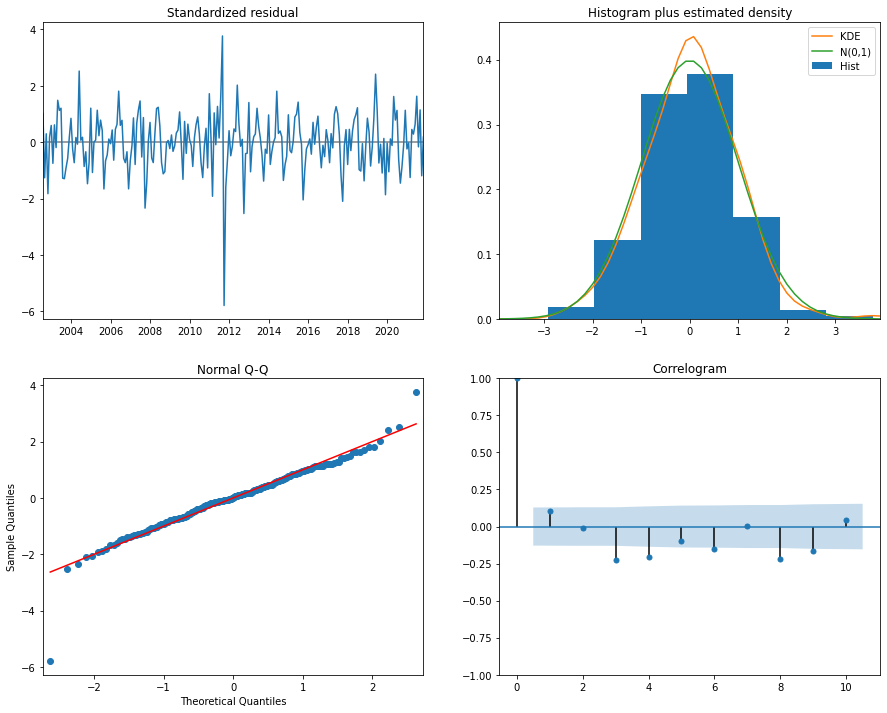

In [11]:
ARIMA_model.plot_diagnostics(figsize=(15,12))
#savedir = os.path.join(main_path, 'xFigure 03_ARIMA_model.plot_diagnostics-monthly m60.png')
#plt.savefig(savedir)
plt.show()

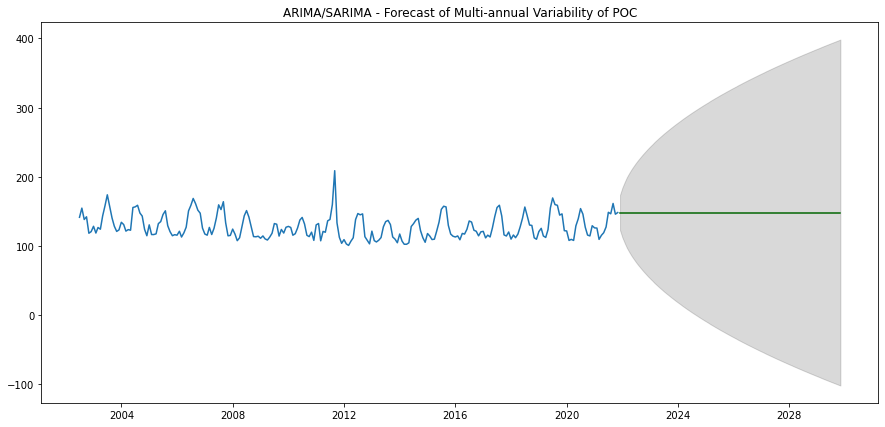

In [12]:
def forecast(ARIMA_model, periods=96):
    # Forecast
    n_periods = periods
    fitted, confint = ARIMA_model.predict(n_periods=n_periods, return_conf_int=True)
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(df["POC"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index, 
                    lower_series, 
                    upper_series, 
                    color='k', alpha=.15)

    plt.title("ARIMA/SARIMA - Forecast of Multi-annual Variability of POC")
    plt.show()

forecast(ARIMA_model)

In [ ]:
# Seasonal - fit stepwise auto-ARIMA
SARIMA_model = pm.auto_arima(df["POC"], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, 
                         m=60, #12 is the frequncy of the cycle; 60 is multi-annual for 5-years cycle
                         start_P=0, 
                         seasonal=True, #set to seasonal
                         d=1, 
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)


In [ ]:
SARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [ ]:
forecast(SARIMA_model)

In [ ]:
model=sm.tsa.statespace.SARIMAX(X.POC,order=(1, 1, 1),seasonal_order=(2,1,0,60))
results=model.fit()

In [ ]:
print(results.summary(), end='\n\n')

In [ ]:
#adding exogenous variable
df['month_index'] = df.index.month

# SARIMAX Model
SARIMAX_model = pm.auto_arima(df[['POC']], exogenous=df[['month_index']],
                           start_p=1, start_q=1,
                           test='adf',
                           max_p=3, max_q=3, m=60, #diubah m=60 untuk multi-annual
                           start_P=0, seasonal=True,
                           d=1, D=1, 
                           trace=False,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)

SARIMAX_model.summary()

In [ ]:
#import os
#import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [ ]:
X['forecast']=results.predict(start='2018-12-01', end='2021-11-01', dynamic=True, alpha=0.05,)
X[['POC','forecast']].plot(figsize=(15,7))
plt.xlabel('Time')
plt.ylabel('POC $(mg/m^3)$')

#savedir = os.path.join(main_path, 'Figure 08_validasi-monthly m60.png')
#plt.savefig(savedir)

plt.show()

In [ ]:
X.head()

In [ ]:
from pandas.tseries.offsets import DateOffset
pred_date = pd.date_range('2021-12-01', '2030-12-01', freq='MS')
pred_date

In [ ]:
pred_date=pd.DataFrame(index=pred_date,columns=X.columns)
pred_date.head()

In [ ]:
X=pd.concat([X,pred_date])

In [ ]:
from matplotlib.dates import YearLocator, DateFormatter
from sklearn.linear_model import LinearRegression


X['forecast'] = results.predict(start='2021-12-31', end='2030-12-31', dynamic=True)

In [ ]:
def sarimax_forecast(SARIMAX_model, periods=96):
    # Forecast
    n_periods = periods

    forecast_df = pd.DataFrame({"month_index":pd.date_range(df.index[-1], periods = n_periods, freq='MS').month},
                    index = pd.date_range(df.index[-1]+ pd.DateOffset(months=1), periods = n_periods, freq='MS'))

    fitted, confint = SARIMAX_model.predict(n_periods=n_periods, 
                                            return_conf_int=True,
                                            exogenous=forecast_df[['month_index']])
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)
    

    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(df["POC"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index, 
                    lower_series, 
                    upper_series, 
                    color='k', alpha=.15)
    
    from matplotlib.dates import YearLocator, DateFormatter
    from sklearn.linear_model import LinearRegression
    X['forecast'] = results.predict(start='2021-12-31', end='2030-12-31', dynamic=True)
    
    # trend of initial/hindcast data
    reg_data = X.POC.dropna()
    index = reg_data.index
    y = reg_data.values
    x = np.arange(len(y)).reshape(-1, 1)

    reg = LinearRegression()
    reg.fit(x, y)
    pred = reg.predict(x)

    ax = plt.subplot()
    ax.plot(index, pred, 'b--', label='Trend of initial data')

    # trend of forecasted data
    reg_data = X.forecast.dropna()
    index = reg_data.index
    y = reg_data.values
    x = np.arange(len(y)).reshape(-1, 1)

    reg = LinearRegression()
    reg.fit(x, y)
    pred = reg.predict(x)

    ax = plt.subplot()
    ax.plot(index, pred, 'r--', label='Trend of forecasted data')
    ax.grid(['x'])
    ax.legend()

    plt.title("SARIMAX - Forecast of Multi-annual Variability of POC")
    plt.xlabel('Time')
    plt.ylabel('POC $(mg/m^3)$')
    plt.show()

sarimax_forecast(SARIMAX_model, periods=96)

savedir = os.path.join(main_path, 'Figure xx_final result-monthly m60.png')
plt.savefig(savedir)

In [ ]:
X['forecast'] = results.predict(start='2021-12-31', end='2030-12-31', dynamic=True)
X.head()
#X.tail()

In [ ]:
print(X.tail(), end='\n\n')
X.tail()

In [ ]:
print(X['forecast'])

In [ ]:
display(X.to_string())

In [ ]:
print(X.to_string())

In [ ]:
from statsmodels.tsa.stattools import acf

# Accuracy metrics
def forecast_accuracy(forecast, POC):
    mape = np.mean(np.abs(forecast - POC)/np.abs(POC))  # MAPE
    me = np.mean(forecast - POC)             # ME
    mae = np.mean(np.abs(forecast - POC))    # MAE
    mpe = np.mean((forecast - POC)/POC)   # MPE
    rmse = np.mean((forecast - POC)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, POC)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None], 
                              POC[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None], 
                              POC[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(forecast-POC)[1]                      # ACF1
    return({'mape':mape, 'me':me, 'mae': mae, 
            'mpe': mpe, 'rmse':rmse, 'acf1':acf1, 
            'corr':corr, 'minmax':minmax})

model=sm.tsa.statespace.SARIMAX(X.POC,order=(1, 1, 1),seasonal_order=(2,1,0,60))
results=model.fit()
fc=results.predict(start='2018-12-01', end='2021-11-01', dynamic=True, alpha=0.05,)

test = X.POC.dropna().loc[fc.index]

forecast_accuracy(fc.values, test.values)

print('=========== Statistic result ===========\n\n')
print(forecast_accuracy(fc.values, test.values))

In [ ]:
#sys.stdout = main_out